# 04. Avaluació del Model ARIMAX amb Variables Farmacocinètiques

En aquest quadern implemente l'algoritme ARIMAX per a la predicció de la glucosa en sang, incorporant l'efecte de variables exògenes (ingesta de carbohidrats i injeccions d'insulina) a l'estructura base prèviament optimitzada del model ARIMA(1,1,0). En aquesta primera secció, configure l'entorn de treball i establisc els paràmetres globals de l'experiment, mantenint una finestra de context d'onze hores i un horitzó de predicció d'una hora. 

A més, definisc tres variants estratègiques per a l'enginyeria de característiques exògenes, dissenyades específicament per a modelar la dinàmica d'absorció fisiològica i evitar problemes de multicolinealitat associats als retards temporals densos.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import os
import matplotlib.pyplot as plt

# Desactivem els avisos de convergència per a visualitzar un output net durant el bucle
warnings.filterwarnings('ignore')

# ============================================================================
# PARÀMETRES CONFIGURABLES GLOBALS
# ============================================================================
MOSTRES_WARMUP = 132   # Finestra d'entrenament local: 11h × 12 mostres/h
MOSTRES_PRED   = 12    # Horitzó de predicció: 1h × 12 mostres/h
SALT_FINESTRA  = 1     # Desplaçament de la finestra temporal (5 min per pas)

IOB_HALFLIFE   = 18    # Semivida de la Insulina Activa (IOB): 18 mostres = 90 min

# Constants d'absorció per als filtres de 2n ordre (Fisiològicament rellevants)
ALPHA_INS_2ND   = 1 / (15 + 1)  # Pic d'acció a la mostra 15 = 75 min
ALPHA_CARBS_2ND = 1 / (9 + 1)   # Pic d'acció a la mostra 9 = 45 min

# Paràmetres configurables dels lags (Variant B espaiada)
LAGS_INS   = list(range(6,  73, 6))   # Retards d'insulina (onset 30m): 30, 60, ..., 360 min
LAGS_CARBS = list(range(3,  73, 6))   # Retards de carbs (onset 15m): 15, 45, ..., 345 min

# ============================================================================
# DEFINICIÓ DE LES EXÒGENES: Variants per a evitar multicolinealitat
# ============================================================================

# VARIANT A (1r Ordre): Insulina Activa (IOB) i Carbohidrats Actius (COB) 
# Dinàmica: Salt brusc inicial i decaïment exponencial.
COLS_EXOG_A = ['iob_exp', 'cob_exp']

# VARIANT B (Lags espaiats): Retards fisiològicament rellevants (12 regressors/variable)
# Dinàmica: Mapeig discret des de l'inici de l'efecte fins a les 6 hores.
COLS_EXOG_B = (
    [f'bolus_lag_{i}' for i in LAGS_INS] + 
    [f'carbs_lag_{i}' for i in LAGS_CARBS]
)

# VARIANT C (2n Ordre): Filtres en cascada per a modelar l'absorció fisiològica
# Dinàmica: Pujada gradual cap al pic d'acció i decaïment suau.
COLS_EXOG_C = ['ins_effect', 'carbs_effect']

# Selecció de la variant principal activa en aquest context
COLS_EXOG = COLS_EXOG_C 

print("Configuració de l'entorn establerta.")
print(f"➜ Variant A (1r Ordre): {len(COLS_EXOG_A)} regressors")
print(f"➜ Variant B (Lags espaiats): {len(COLS_EXOG_B)} regressors")
print(f"➜ Variant C (2n Ordre): {len(COLS_EXOG_C)} regressors")

Configuració de l'entorn establerta.
➜ Variant A (1r Ordre): 2 regressors
➜ Variant B (Lags espaiats): 24 regressors
➜ Variant C (2n Ordre): 2 regressors


### 1. Enginyeria de Característiques (Feature Engineering)

En aquesta secció, cree les variables exògenes necessàries per a dotar el model de context fisiològic. Per a avaluar diferents hipòtesis de modelització, implemente tres variants:
1. **Filtres de 1r Ordre (Variant A):** Calcule l'Insulina Activa (IOB) i els Carbohidrats Actius (COB) mitjançant filtres de decaïment exponencial simples (salt brusc i caiguda).
2. **Lags espaiats (Variant B):** Genere columnes de retards per a capturar l'efecte diferit de la insulina i la ingesta nutricional, espaiats cada 30 minuts dins d'una finestra d'acció fisiològica realista per a evitar la multicolinealitat densa.
3. **Filtres de 2n Ordre en cascada (Variant C):** Dissenye filtres IIR de segon ordre descomposats en dues etapes. Això em permet modelar la corba d'absorció fisiològica real (pujada suau cap al pic i decaïment), alhora que guarde l'estat intern (`s1`) necessari per a propagar l'efecte futur sense utilitzar dades desconegudes durant la predicció.

Aplique aquestes transformacions respectant de manera estricta els límits de cada segment continu per a evitar qualsevol tipus de contaminació temporal (*data leakage*).

In [2]:
# =============================================================================
# 1. ENGINYERIA DE CARACTERÍSTIQUES (Feature Engineering)
# =============================================================================

def filtre_primer_ordre(x, alpha):
    """
    Filtre IIR de 1r ordre.
    Resposta a l'impuls: salt brusc inicial i decaïment exponencial.
    """
    y = np.zeros(len(x))
    for n in range(len(x)):
        y[n] = x[n] if n == 0 else x[n] + (1 - alpha) * y[n - 1]
    return y

def enginyeria_caracteristiques(df, lags_ins=LAGS_INS, lags_carbs=LAGS_CARBS, iob_halflife=IOB_HALFLIFE):
    df = df.copy().sort_values(['pacient_id', 'segment_num', 'timestamp'])

    # ---------------------------------------------------------
    # A. Lags espaiats fisiològicament (Variant B)
    # ---------------------------------------------------------
    for lag in lags_ins:
        df[f'bolus_lag_{lag}'] = df.groupby(['pacient_id', 'segment_num'])['bolus'].shift(lag).fillna(0)
        
    for lag in lags_carbs:
        df[f'carbs_lag_{lag}'] = df.groupby(['pacient_id', 'segment_num'])['carbs'].shift(lag).fillna(0)

    # ---------------------------------------------------------
    # B. Filtres de 1r Ordre: IOB i COB (Variant A)
    # ---------------------------------------------------------
    alpha_iob = 1 - np.exp(-np.log(2) / iob_halflife)
    ALPHA_CARBS_1ST = 1 - np.exp(-np.log(2) / 9)   # semivida 9 mostres (45 min)
    
    df['iob_exp'] = df.groupby(['pacient_id', 'segment_num'])['bolus'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, alpha_iob), index=s.index))
        
    df['cob_exp'] = df.groupby(['pacient_id', 'segment_num'])['carbs'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, ALPHA_CARBS_1ST), index=s.index))

    # ---------------------------------------------------------
    # C. Filtres de 2n Ordre en cascada (Variant C)
    # ---------------------------------------------------------
    
    # Etapa 1 (s1): Estat intern (pòsit) per a la propagació causal futura
    df['ins_s1'] = df.groupby(['pacient_id', 'segment_num'])['bolus'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, ALPHA_INS_2ND), index=s.index))
        
    df['carbs_s1'] = df.groupby(['pacient_id', 'segment_num'])['carbs'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, ALPHA_CARBS_2ND), index=s.index))

    # Etapa 2 (effect): Efecte fisiològic final (corba suauitzada)
    df['ins_effect'] = df.groupby(['pacient_id', 'segment_num'])['ins_s1'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, ALPHA_INS_2ND), index=s.index))
        
    df['carbs_effect'] = df.groupby(['pacient_id', 'segment_num'])['carbs_s1'].transform(
        lambda s: pd.Series(filtre_primer_ordre(s.values, ALPHA_CARBS_2ND), index=s.index))

    return df

# Càrrega de dades preprocessades
df_train = pd.read_csv("dades_preprocessades/dataset_entrenament_net.csv")
df_test  = pd.read_csv("dades_preprocessades/dataset_test_net.csv")

# Validació de qualitat del dataset
assert df_train.groupby(['pacient_id', 'segment_num']).size().min() >= 144, "Error: Segment curt en Train."
assert df_test.groupby(['pacient_id', 'segment_num']).size().min() >= 144, "Error: Segment curt en Test."
print("✅ Validació correcta: Tots els segments compleixen el llindar de 12h.")

# Aplicació de l'enginyeria
df_train = enginyeria_caracteristiques(df_train)
df_test  = enginyeria_caracteristiques(df_test)

print(f"✅ Variables generades correctament. df_train té ara {df_train.shape[1]} columnes.")

✅ Validació correcta: Tots els segments compleixen el llindar de 12h.
✅ Variables generades correctament. df_train té ara 37 columnes.


### 2. Visualització Comparativa: Validació dels Models Farmacocinètics

Abans de procedir a la calibració de l'ARIMAX, valide visualment el comportament de les transformacions aplicades a les variables exògenes. Seleccione el pacient 559 com a subjecte d'exemple i compare la resposta temporal del filtre de primer ordre (Variant A) respecte al filtre de segon ordre en cascada (Variant C).

L'objectiu és confirmar que la Variant C corregeix el salt instantani i irreal del primer ordre, oferint una corba suauitzada que assoleix el pic d'efectivitat metabòlica al cap de 75 minuts per a la insulina ràpida i 45 minuts per a l'absorció de carbohidrats.

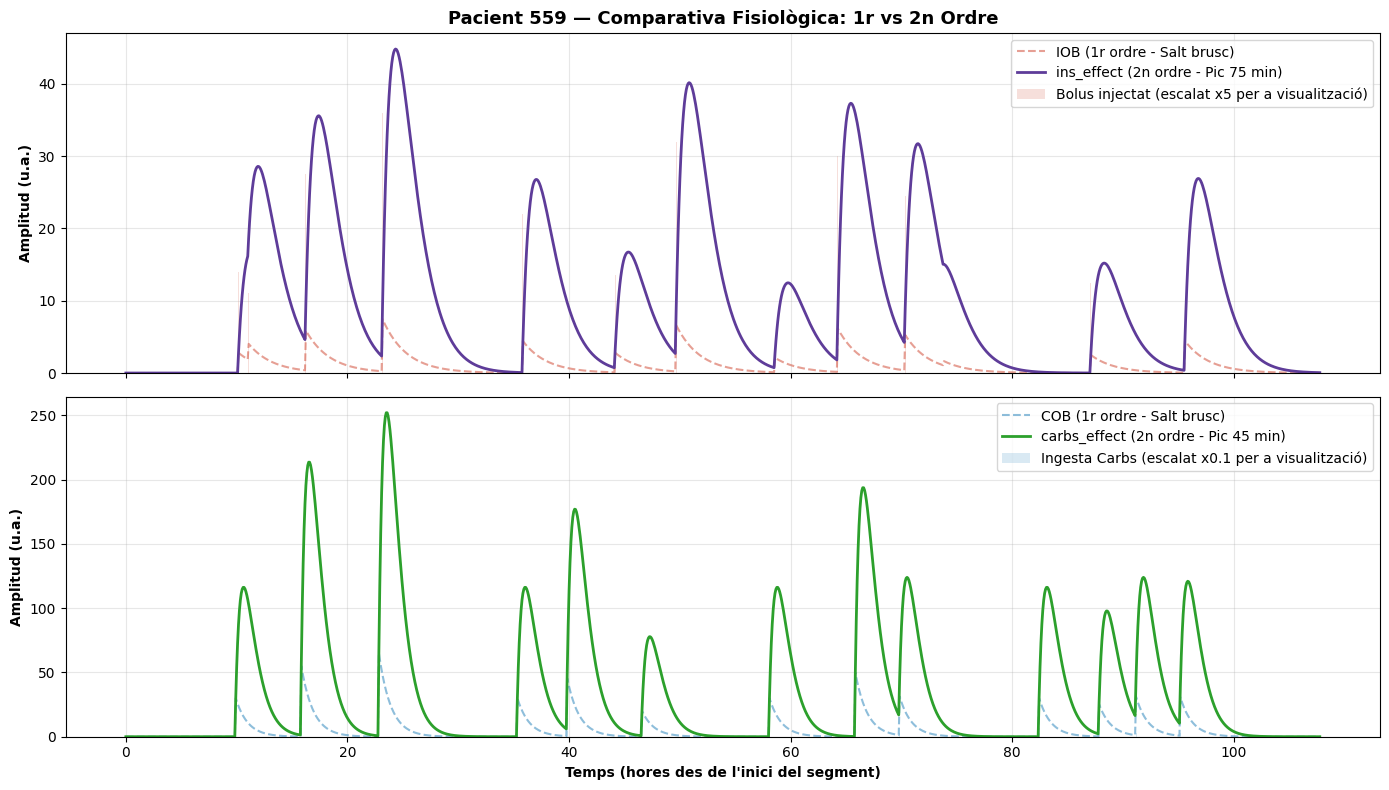

✅ Gràfica comparativa generada i guardada a 'resultats_grafics/resultats_finals\comparativa_1r_2n_ordre.png'


In [3]:
# =============================================================================
# 2. VISUALITZACIÓ: COMPARATIVA 1R ORDRE (Variant A) VS 2N ORDRE (Variant C)
# =============================================================================

# 1. Definim el pacient d'exemple i busquem el seu segment continu més llarg
pac_ex = 559
mides_segments = df_train.groupby(['pacient_id', 'segment_num']).size().reset_index(name='longitud')
seg_ex         = mides_segments[mides_segments['pacient_id'] == pac_ex]['longitud'].idxmax()
seg_num_ex     = mides_segments.loc[seg_ex, 'segment_num']

# 2. Recuperem les dades exactes d'eixe segment
df_ex = df_train[
    (df_train['pacient_id'] == pac_ex) & 
    (df_train['segment_num'] == seg_num_ex)
].sort_values('timestamp').reset_index(drop=True)

# 3. Generem la gràfica
hores = df_ex.index * 5 / 60
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Subgràfica 1: Dinàmica de la Insulina ---
axes[0].plot(hores, df_ex['iob_exp'], color='#D6604D', linewidth=1.5, alpha=0.6, linestyle='--', label='IOB (1r ordre - Salt brusc)')
axes[0].plot(hores, df_ex['ins_effect'], color='#5E3C99', linewidth=2, label='ins_effect (2n ordre - Pic 75 min)')
axes[0].bar(hores, df_ex['bolus'] * 5, color='#D6604D', alpha=0.2, width=5/60, label='Bolus injectat (escalat x5 per a visualització)')
axes[0].set_ylabel("Amplitud (u.a.)", fontweight='bold')
axes[0].set_title(f"Pacient {pac_ex} — Comparativa Fisiològica: 1r vs 2n Ordre", fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# --- Subgràfica 2: Dinàmica dels Carbohidrats ---
axes[1].plot(hores, df_ex['cob_exp'], color='#4393C3', linewidth=1.5, alpha=0.6, linestyle='--', label='COB (1r ordre - Salt brusc)')
axes[1].plot(hores, df_ex['carbs_effect'], color='#2CA02C', linewidth=2, label='carbs_effect (2n ordre - Pic 45 min)')
axes[1].bar(hores, df_ex['carbs'] * 0.1, color='#4393C3', alpha=0.2, width=5/60, label='Ingesta Carbs (escalat x0.1 per a visualització)')
axes[1].set_ylabel("Amplitud (u.a.)", fontweight='bold')
axes[1].set_xlabel("Temps (hores des de l'inici del segment)", fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()

# 4. Exportació de la gràfica per a la memòria del TFG
carpeta_grafiques = "resultats_grafics/resultats_finals"
os.makedirs(carpeta_grafiques, exist_ok=True)
ruta = os.path.join(carpeta_grafiques, "comparativa_1r_2n_ordre.png")
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gràfica comparativa generada i guardada a '{ruta}'")

### 3. Funcions Auxiliars per a la Predicció Causal

Per a garantir que el model predictiu siga realista i no utilitze informació futura (*data leakage*), necessite simular l'evolució de les variables exògenes durant l'horitzó de predicció (d'1 a 60 minuts en el futur) assumint que el pacient no realitza cap acció nova. 

En la **Variant C**, com que utilitze un filtre IIR de segon ordre descomposat en cascada, puc aprofitar l'estat intermedi del filtre (`s1`) per a propagar la inèrcia de la insulina i els carbohidrats que ja estan dins del sistema cap avant en el temps. Aquesta funció s'encarregarà de calcular eixe decaïment natural.

In [4]:
# =============================================================================
# 3. FUNCIONS AUXILIARS PER A LA PREDICCIÓ CAUSAL
# =============================================================================

def propagar_efecte_futur(s1_final, s2_final, alpha, n_steps):
    """
    Propaga l'estat del filtre de 2n ordre cap avant sense entrada nova.
    Modela el principi biològic: "la insulina/carbohidrats ja presents en 
    el sistema continuen fent efecte durant la finestra de predicció, 
    sense que el pacient ingerixca o s'injecte res nou."
    
    Paràmetres:
    - s1_final: últim valor conegut de l'etapa 1 (estat intermedi del filtre)
    - s2_final: últim valor conegut de l'etapa 2 (efecte actual, ex. ins_effect)
    - alpha: el coeficient de decaïment del filtre de la variable
    - n_steps: horitzó temporal a predir (nombre de mostres futures)
    
    Retorna:
    - vals: array amb l'evolució projectada de l'efecte exogen.
    """
    vals = np.zeros(n_steps)
    s1, s2 = s1_final, s2_final
    
    for k in range(n_steps):
        s1 = (1 - alpha) * s1       # Com que no hi ha entrada (x=0), l'estat 1 decau purament
        s2 = s1 + (1 - alpha) * s2  # L'estat 2 rep el romanent de l'estat 1 i també decau
        vals[k] = s2
        
    return vals

print("✅ Funció de propagació d'estats carregada.")

✅ Funció de propagació d'estats carregada.


### 4. Calibració de Coeficients ARIMAX per a les Diferents Variants

En aquesta etapa, ajuste els paràmetres del model ARIMAX(1,1,0) per a cada pacient i variant de l'estudi. Per a mantenir la coherència metodològica amb l'avaluació de la línia base de referència, realitze l'entrenament exclusivament sobre el segment continu més llarg disponible en el conjunt d'entrenament de cada subjecte. 

L'objectiu és extreure i emmagatzemar els coeficients optimitzats tant per a la Variant C (filtres de segon ordre) com per a la Variant B (lags espaiats). Aquests pesos s'injectaran posteriorment en l'estat del filtre de Kalman per a l'avaluació predictiva contínua.

In [5]:
# =============================================================================
# 4. CALIBRACIÓ DE COEFICIENTS ARIMAX(1,1,0)
# =============================================================================

print("1. Calibrant coeficients ARIMAX(1,1,0) per a cada pacient...")

dic_coefs_pacient = {}
resultats_coefs   = []

# Identifiquem el segment continu més llarg per a cada pacient en el conjunt d'entrenament
mides_segments      = df_train.groupby(['pacient_id', 'segment_num']).size().reset_index(name='longitud')
idx_max             = mides_segments.groupby('pacient_id')['longitud'].idxmax()
segments_mes_llargs = mides_segments.loc[idx_max]

for _, row in segments_mes_llargs.iterrows():
    pacient = row['pacient_id']
    seg_num = row['segment_num']

    # Recuperem les dades d'entrenament d'eixe segment específic
    df_seg = df_train[
        (df_train['pacient_id'] == pacient) &
        (df_train['segment_num'] == seg_num)
    ].sort_values('timestamp')

    y = df_seg['glucose_imputed'].values
    
    # Inicialitzem el sub-diccionari per a guardar els pesos de totes les variants
    dic_coefs_pacient[pacient] = {}

    # ── ENTRENAMENT VARIANT C (2n Ordre - Principal) ──
    exog_C  = df_seg[COLS_EXOG_C].fillna(0) 
    model_C = ARIMA(y, exog=exog_C, order=(1, 1, 0))
    res_C   = model_C.fit()
    dic_coefs_pacient[pacient]['C_2n_ordre'] = res_C.params

    # ── ENTRENAMENT VARIANT B (Lags espaiats) ──
    exog_B  = df_seg[COLS_EXOG_B].fillna(0)
    model_B = ARIMA(y, exog=exog_B, order=(1, 1, 0))
    res_B   = model_B.fit()
    dic_coefs_pacient[pacient]['B_lags'] = res_B.params

    # Extraiem els coeficients de la Variant C per a tindre un resum visual net per a la memòria
    pnames = list(res_C.param_names)
    resultats_coefs.append({
        'Pacient'     : pacient,
        'AR(1)'       : round(res_C.params[pnames.index('ar.L1')], 4),
        'Sigma2'      : round(res_C.params[pnames.index('sigma2')], 4),
        'Coef_Ins'    : round(res_C.params[pnames.index('ins_effect')], 4),
        'Coef_Carbs'  : round(res_C.params[pnames.index('carbs_effect')], 4),
    })
    
df_coefs_final = pd.DataFrame(resultats_coefs)
print("✅ Calibració finalitzada i coeficients d'ambdues variants emmagatzemats.")
display(df_coefs_final.head())

1. Calibrant coeficients ARIMAX(1,1,0) per a cada pacient...
✅ Calibració finalitzada i coeficients d'ambdues variants emmagatzemats.


,Pacient,AR(1),Sigma2,Coef_Ins,Coef_Carbs
0,559,0.6008,26.3875,0.6909,0.0433
1,563,0.5878,13.5700,0.0433,0.0134
2,570,0.6559,10.9266,0.1199,0.0071
3,575,0.7059,9.1408,0.7825,0.0381
4,588,0.6727,12.1621,0.0376,-0.0101


### 5. Diagnòstic de Residus del Model

Per a concloure l'avaluació i validar estadísticament la robustesa de l'ajust ARIMAX(1,1,0), genere l'anàlisi de diagnòstic de residus mitjançant la funció `plot_diagnostics`. Seleccione el pacient d'exemple (559) i avalue els errors del model sobre el seu segment continu de calibració, comparant els resultats per a les dues variants d'estudi.

Aquesta anàlisi és fonamental per a comprovar si els residus es comporten com a soroll blanc gaussià. Els resultats mostren un correlograma (ACF) sense autocorrelació residual significativa, la qual cosa indica que l'estructura AR(1) combinada amb les exògenes ha capturat tota la informació dinàmica disponible. D'altra banda, s'observa una distribució leptocúrtica en l'histograma i desviacions en les cues del Q-Q Plot. Aquest comportament de "cues pesades" és l'esperat en dades de Monitoratge Continu de Glucosa (CGM), atès que reflecteix la naturalesa dels esdeveniments glucèmics extrems (com hipoglucèmies ràpides), els quals s'aparten per definició del comportament autoregressiu habitual.

Generant diagnòstic de residus per a les variants C (2n ordre) i B (lags)...


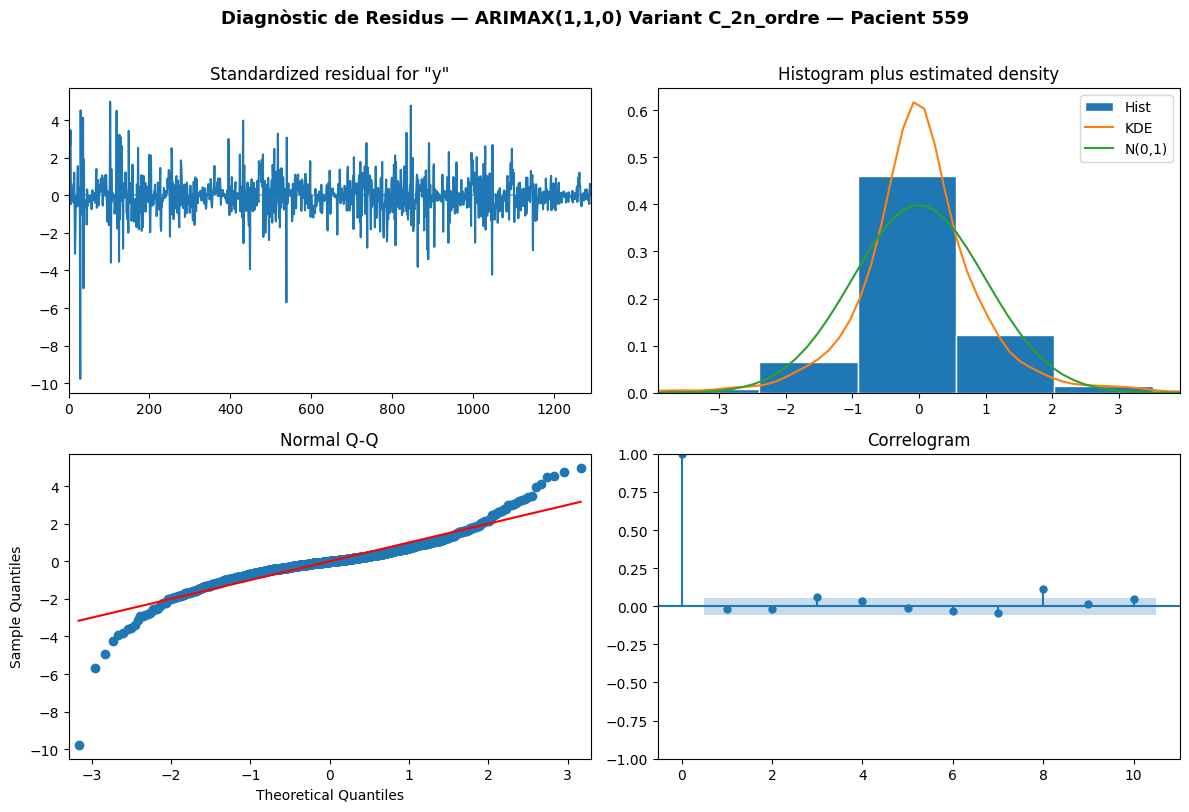

✅ Gràfica generada a 'resultats_grafics/resultats_finals\diagnostics_residus_C_2n_ordre_p559.png'


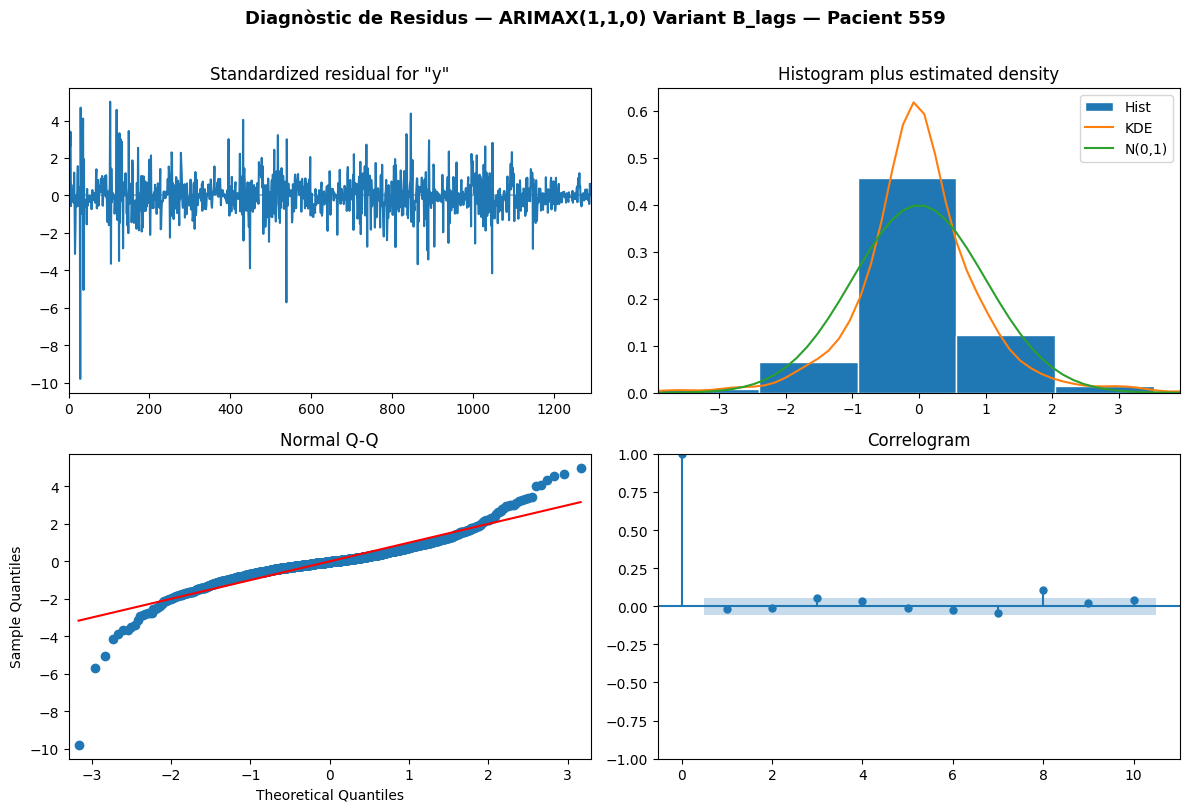

✅ Gràfica generada a 'resultats_grafics/resultats_finals\diagnostics_residus_B_lags_p559.png'


In [6]:
# =============================================================================
# 5. DIAGNÒSTIC DE RESIDUS (plot_diagnostics)
# =============================================================================

print("Generant diagnòstic de residus per a les variants C (2n ordre) i B (lags)...")

# Assegurem que el directori de gràfiques existeix
carpeta_grafiques = "resultats_grafics/resultats_finals"
import os
os.makedirs(carpeta_grafiques, exist_ok=True)

# Generem els gràfics per a ambdues variants
for variant_nom, cols_exog in [('C_2n_ordre', COLS_EXOG_C), ('B_lags', COLS_EXOG_B)]:
    
    # 1. Selecció del pacient i segment
    pac = 559
    seg_num_fit = segments_mes_llargs[
        segments_mes_llargs['pacient_id'] == pac]['segment_num'].values[0]
    
    df_seg_fit = df_train[
        (df_train['pacient_id'] == pac) &
        (df_train['segment_num'] == seg_num_fit)
    ].sort_values('timestamp')
    
    y    = df_seg_fit['glucose_imputed'].values
    exog = df_seg_fit[cols_exog].fillna(0)
    
    # 2. Ajust del model (sense guardar prediccions, només per a extraure els residus)
    res = ARIMA(y, exog=exog, order=(1, 1, 0)).fit()
    
    # 3. Generació del panell de diagnòstic (4 subgràfiques)
    fig = res.plot_diagnostics(figsize=(12, 8))
    fig.suptitle(
        f"Diagnòstic de Residus — ARIMAX(1,1,0) Variant {variant_nom} — Pacient {pac}",
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    
    # 4. Exportació
    ruta = os.path.join(carpeta_grafiques, f"diagnostics_residus_{variant_nom}_p{pac}.png")
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gràfica generada a '{ruta}'")

### 6. Avaluació en Test mitjançant Finestra Lliscant Causal

Avalue la capacitat predictiva real de les dues variants del model ARIMAX mitjançant una validació de pas endavant. Implemente una estructura de finestra lliscant que utilitza 11 hores de context històric (`MOSTRES_WARMUP`) per a inicialitzar el filtre de Kalman de l'algorisme statsmodels amb els coeficients prèviament calibrats.

Per a garantir un escenari de predicció realista i estrictament causal, el bucle projecta el comportament futur de les exògenes a una hora vista (`MOSTRES_PRED`) de dues maneres:
1. **Variant C (2n Ordre):** Propaga matemàticament l'estat d'inèrcia dels filtres a partir del darrer punt conegut de l'etapa intermediària (`s1`), modelant com es dilueix l'efecte de la insulina i el menjar ja presents en el cos.
2. **Variant B (Lags espaiats):** Omple amb zeros els valors futurs, assumint que no es produiran noves injeccions ni ingesta durant l'horitzó d'una hora.

In [7]:
# =============================================================================
# 6. BUCLE D'AVALUACIÓ PREDICTIVA SENSE CONTAMINACIÓ TEMPORAL
# =============================================================================

prediccions_test = []

print("Iniciant l'avaluació predictiva per a tots els pacients en el dataset de test...")

# Bucle exterior: Processament independent per pacient
for pacient, df_pacient in df_test.groupby('pacient_id'):
    
    if pacient not in dic_coefs_pacient:
        print(f"⚠️ Alerta: El pacient {pacient} no té coeficients calibrats. Saltant...")
        continue
        
    params_pacient = dic_coefs_pacient[pacient]

    # Bucle intermedi: Processament independent per segment continu
    for seg_num, df_seg in df_pacient.groupby('segment_num'):
        df_seg    = df_seg.sort_values('timestamp').reset_index(drop=True)
        y_test    = df_seg['glucose_imputed'].values
        n_mostres = len(y_test)

        # Extracció indexada de vectors del segment per a optimitzar el temps d'execució
        ins_s1_seg       = df_seg['ins_s1'].values
        ins_effect_seg   = df_seg['ins_effect'].values
        carbs_s1_seg     = df_seg['carbs_s1'].values
        carbs_effect_seg = df_seg['carbs_effect'].values
        bolus_seg        = df_seg['bolus'].values
        carbs_seg        = df_seg['carbs'].values
        
        exog_seg_C       = df_seg[COLS_EXOG_C].fillna(0).values  # Matriu Variant C [N × 2]
        exog_seg_B       = df_seg[COLS_EXOG_B].fillna(0).values  # Matriu Variant B [N × 24]

        # Bucle intern: Finestra mòbil de pas endavant
        for i in range(0, n_mostres - MOSTRES_WARMUP - MOSTRES_PRED + 1, SALT_FINESTRA):
            end_wu = i + MOSTRES_WARMUP   # Final del context / Inici del pronòstic

            y_warmup     = y_test[i:end_wu]
            y_real_futur = y_test[end_wu:end_wu + MOSTRES_PRED]

            # ── VARIANT C (2n Ordre): Propagació determinista de l'estat intern ──
            ins_effect_futur   = propagar_efecte_futur(
                ins_s1_seg[end_wu - 1], ins_effect_seg[end_wu - 1],
                ALPHA_INS_2ND, MOSTRES_PRED)
            carbs_effect_futur = propagar_efecte_futur(
                carbs_s1_seg[end_wu - 1], carbs_effect_seg[end_wu - 1],
                ALPHA_CARBS_2ND, MOSTRES_PRED)
            exog_futur_C = np.column_stack([ins_effect_futur, carbs_effect_futur])

            # ── VARIANT B (Lags espaiats): Assignació de zeros per a inputs futurs ──
            exog_futur_B = np.zeros((MOSTRES_PRED, len(COLS_EXOG_B)))
            for k in range(MOSTRES_PRED):
                col = 0
                for lag in LAGS_INS:
                    src = end_wu + k - lag
                    if 0 <= src < end_wu:
                        exog_futur_B[k, col] = bolus_seg[src]
                    col += 1
                for lag in LAGS_CARBS:
                    src = end_wu + k - lag
                    if 0 <= src < end_wu:
                        exog_futur_B[k, col] = carbs_seg[src]
                    col += 1

            # ── AVALUACIÓ I FILTRAT DE KALMAN ──
            timestamp_pred = df_seg['timestamp'].iloc[end_wu - 1]

            for variant_nom, cols_exog, exog_futur in [
                ('C_2n_ordre', COLS_EXOG_C, exog_futur_C),
                ('B_lags',     COLS_EXOG_B, exog_futur_B),
            ]:
                exog_warmup = exog_seg_C[i:end_wu] if variant_nom.startswith('C') else exog_seg_B[i:end_wu]
                
                # Instanciació local del model sobre la finestra de context
                model_eval   = ARIMA(y_warmup, exog=exog_warmup, order=(1, 1, 0))
                # Apliquem el filtre de Kalman utilitzant els coeficients calibrats fixos
                res_eval     = model_eval.filter(params_pacient[variant_nom])
                
                # Projecció dels 12 passos futurs (60 minuts)
                preds        = res_eval.forecast(steps=MOSTRES_PRED, exog=exog_futur)
                pred_vals    = preds.values if hasattr(preds, 'values') else np.array(preds)

                # Emmagatzematge de resultats reals vs. predits
                prediccions_test.append({
                    'Variant'       : variant_nom,
                    'Pacient'       : pacient,
                    'Timestamp_Pred': timestamp_pred,
                    'Real_15m'      : y_real_futur[2],  'Pred_15m': pred_vals[2],
                    'Real_30m'      : y_real_futur[5],  'Pred_30m': pred_vals[5],
                    'Real_45m'      : y_real_futur[8],  'Pred_45m': pred_vals[8],
                    'Real_60m'      : y_real_futur[11], 'Pred_60m': pred_vals[11],
                })

df_prediccions_test = pd.DataFrame(prediccions_test)
print(f"✅ Avaluació finalitzada. S'han generat {len(df_prediccions_test)} files de prediccions.")

Iniciant l'avaluació predictiva per a tots els pacients en el dataset de test...
✅ Avaluació finalitzada. S'han generat 22788 files de prediccions.


### 7. Resum de Mètriques Globals i Exportació de Resultats

Una vegada finalitzada l'avaluació massiva, procedisc a quantificar el rendiment predictiu de les diferents estratègies de modelització. Per a proporcionar una avaluació clínica i estadística rigorosa, calcule les mètriques d'error estàndard (RMSE i MAE) i l'Error Relatiu Absolut Mitjà (MARD, *Mean Absolute Relative Difference*), incloent protecció matemàtica contra divisions per zero.

Aquesta anàlisi permet comparar de manera directa la capacitat d'extrapolació de la Variant C (model fisiològic de segon ordre) front a la Variant B (lags espaiats). Finalment, exporte les prediccions completes, les mètriques globals i els coeficients calibrats individualitzats per a la seua inclusió a la memòria final del projecte.

In [8]:
# =============================================================================
# 7. RESUM DE MÈTRIQUES GLOBALS I EXPORTACIÓ
# =============================================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

def calcular_metriques(real, pred):
    """Calcula RMSE, MAE i MARD amb protecció per valors reals iguals a zero."""
    rmse = np.sqrt(mean_squared_error(real, pred))
    mae  = mean_absolute_error(real, pred)
    mard = np.nanmean(np.abs((real - pred) / np.where(real == 0, np.nan, real))) * 100
    return rmse, mae, mard

taula_metriques = []

# Iterem per cada variant per a poder comparar el seu rendiment a la taula final
for variant in df_prediccions_test['Variant'].unique():
    df_var = df_prediccions_test[df_prediccions_test['Variant'] == variant]
    
    for h in ['15m', '30m', '45m', '60m']:
        rmse, mae, mard = calcular_metriques(df_var[f'Real_{h}'], df_var[f'Pred_{h}'])
        taula_metriques.append({
            'Variant'      : variant,
            'Horitzó'      : h, 
            'RMSE (mg/dL)' : round(rmse, 2),
            'MAE (mg/dL)'  : round(mae, 2), 
            'MARD (%)'     : round(mard, 2)
        })

df_metriques = pd.DataFrame(taula_metriques)

print("\n" + "="*70)
print(" TAULA 1: RESULTATS PER VARIANT EN TEST")
print("="*70)
print(df_metriques.to_string(index=False))

print("\n" + "="*70)
print(" TAULA 2: COEFICIENTS INDIVIDUALITZATS PER PACIENT")
print("="*70)
print(df_coefs_final.to_string(index=False))

# ── Exportació de Dades ──
import os
os.makedirs("resultats_metrics", exist_ok=True)

df_prediccions_test.to_csv("resultats_metrics/prediccions_arimax_test.csv", index=False)
df_metriques.to_csv("resultats_metrics/arimax_metriques_test.csv", index=False)
df_coefs_final.to_csv("resultats_metrics/arimax_coeficients_pacients.csv", index=False)

print("\n✅ Exportació completada amb èxit.")


 TAULA 1: RESULTATS PER VARIANT EN TEST
   Variant Horitzó  RMSE (mg/dL)  MAE (mg/dL)  MARD (%)
C_2n_ordre     15m         12.52         7.81      5.04
C_2n_ordre     30m         21.23        14.40      9.27
C_2n_ordre     45m         28.49        20.19     13.01
C_2n_ordre     60m         34.69        25.13     16.31
    B_lags     15m         12.75         7.88      5.08
    B_lags     30m         21.70        14.58      9.37
    B_lags     45m         29.07        20.44     13.17
    B_lags     60m         35.30        25.45     16.52

 TAULA 2: COEFICIENTS INDIVIDUALITZATS PER PACIENT
 Pacient  AR(1)  Sigma2  Coef_Ins  Coef_Carbs
     559 0.6008 26.3875    0.6909      0.0433
     563 0.5878 13.5700    0.0433      0.0134
     570 0.6559 10.9266    0.1199      0.0071
     575 0.7059  9.1408    0.7825      0.0381
     588 0.6727 12.1621    0.0376     -0.0101
     591 0.7641  9.7268    0.0402     -0.0164

✅ Exportació completada amb èxit.


### 8. Avaluació Clínica: Rendiment en la Detecció d'Hipoglucèmies

Per a complementar l'avaluació estrictament matemàtica de l'algorisme ARIMAX, traduesc les prediccions contínues a un format de classificació binària clínicament rellevant. Establisc el llindar de risc crític en valors de glucosa menors o iguals a 70 mg/dL. 

A partir de la matriu de confusió generada per a cada finestra i horitzó temporal (Veritables Positius, Falsos Negatius i Falsos Positius), calcule el rendiment del model a l'hora d'anticipar esdeveniments crítics. L'objectiu és avaluar de quina manera la integració de la farmacocinètica i els filtres de segon ordre permeten optimitzar la sensibilitat (*recall*) i l'F1-Score, minimitzant els falsos negatius (omissions de crisis glicèmiques), una propietat fonamental en entorns d'assistència mèdica.

In [9]:
# =============================================================================
# 8. AVALUACIÓ CLÍNICA: DETECCIÓ D'HIPOGLUCÈMIES
# =============================================================================

LLINDAR_HIPO = 70.0
resultats_hipo = []

# Iterem per cada variant (B_lags i C_2n_ordre) per a contrastar el comportament clínic
for variant in df_prediccions_test['Variant'].unique():
    df_var = df_prediccions_test[df_prediccions_test['Variant'] == variant]
    
    for h in ['15m', '30m', '45m', '60m']:
        y_true = df_var[f'Real_{h}'].values
        y_pred = df_var[f'Pred_{h}'].values

        # Binarització de les variables segons el criteri clínic d'hipoglucèmia
        real_hipo = (y_true <= LLINDAR_HIPO)
        pred_hipo = (y_pred <= LLINDAR_HIPO)

        # Càlcul de components de la matriu de confusió
        tp = np.sum(real_hipo & pred_hipo)   # Veritables Positius (Detectats correctament)
        fn = np.sum(real_hipo & ~pred_hipo)  # Falsos Negatius (Casos omesos)
        fp = np.sum(~real_hipo & pred_hipo)  # Falsos Positius (Falses alarmes)
        
        # Càlcul de mètriques de classificació amb protecció per divisió zero
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        resultats_hipo.append({
            'Variant'           : variant,
            'Horitzó'           : h,
            'TP (Detectats)'    : int(tp),
            'FN (Omesos)'       : int(fn),
            'Recall (%)'        : round(recall * 100, 2),
            'F1-Score (%)'      : round(f1 * 100, 2)
        })

df_hipo = pd.DataFrame(resultats_hipo)

print("\n" + "="*80)
print(" TAULA 3: DETECCIÓ D'HIPOGLUCÈMIES — COMPARATIVA PER VARIANT")
print("="*80)
print(df_hipo.to_string(index=False))

# Exportació de resultats de classificació clínica
df_hipo.to_csv("resultats_metrics/arimax_hipoglucemies_comparativa.csv", index=False)
print("\n✅ Exportació de mètriques clíniques completada.")


 TAULA 3: DETECCIÓ D'HIPOGLUCÈMIES — COMPARATIVA PER VARIANT
   Variant Horitzó  TP (Detectats)  FN (Omesos)  Recall (%)  F1-Score (%)
C_2n_ordre     15m             189           47       80.08         75.45
C_2n_ordre     30m             148           90       62.18         55.53
C_2n_ordre     45m             122          121       50.21         43.81
C_2n_ordre     60m              90          156       36.59         31.47
    B_lags     15m             188           48       79.66         74.90
    B_lags     30m             147           91       61.76         54.55
    B_lags     45m             121          122       49.79         43.29
    B_lags     60m              87          159       35.37         30.96

✅ Exportació de mètriques clíniques completada.
